# 🧹 Homework — O quão boa é essa base? 

**Autor:** Mateus Cortez
**Entidade:** Insper Data — Ciclo Básico  
**Data:** 03 de setembro de 2026

---
### ⚠️ Diagnóstico de Sobrevivência
A limpeza de dados não é um capricho estético; é a diferença entre uma análise que gera lucro e uma que gera prejuízo. O objetivo aqui é simples: **provar com números o quão suja a base está e o quanto conseguimos salvá-la.**

Neste entregável, você deve:
1.  **Diagnosticar:** Encontrar onde a base dói (missing, tipos errados, duplicatas).
2.  **Medir:** Criar um score matemático de qualidade.
3.  **Limpar:** Aplicar as regras mínimas de saneamento.
4.  **Comparar:** Mostrar o ganho de qualidade real através do seu score.

In [85]:
import pandas as pd
import numpy as np
import re
from dateutil import parser
from datetime import datetime
import matplotlib.pyplot as plt

# --- HELPERS DE CONVERSÃO ---

def to_float_safe(x):
    """Converte string com vírgula/sujeira em float."""
    try: 
        return float(str(x).replace(',', '.'))
    except: 
        return np.nan

def to_int_safe(x):
    """Converte valores numéricos para int (lida com floats de sistema)."""
    try: 
        return int(float(x))
    except: 
        return np.nan

def parse_date_safe(x):
    """Parse de data inteligente (ajuda com diferentes formatos de string)."""
    try: 
        return parser.parse(str(x))
    except: 
        return pd.NaT

# --- HELPERS DE VALIDAÇÃO E LIMPEZA ---

def clean_string(x):
    """Padronização básica: remove espaços e coloca em minúsculo."""
    if pd.isna(x): return np.nan
    return str(x).strip().lower()

def validate_email(email):
    """Valida se o formato do e-mail é aceitável via Regex."""
    if pd.isna(email): return False
    pattern = r'^[\w\.-]+@[\w\.-]+\.\w+$'
    return bool(re.match(pattern, str(email)))

def pct(x, total):
    """Gera string de porcentagem formatada para relatórios."""
    if total == 0: return "0 (0.00%)"
    return f"{int(x)} ({100*x/total:.2f}%)"

def get_outliers_iqr(df, column):
    """Detecta outliers usando a regra do Intervalo Interquartil (IQR)."""
    series = df[column].apply(to_float_safe).dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (series < lower_bound) | (series > upper_bound)


df = pd.read_csv("data/vendas.csv", dtype=object)



---
### 🫵🫵Agora é contigo, use os helpers e responda: Essa base é boa para se usar? Quais métricas são interessantes?
---

In [86]:
df.head(5)

,id_venda,id_cliente,data_venda,categoria,valor_venda,quantidade,desconto,devolvido,pago,forma_pagamento,cidade_entrega,obs
0,6384,452.0,2024-08-11 00:00:00,Alimentos,25.8,3.0,0.0,False,False,NaN,CTBA,telefone inválido
1,4167,188.0,2024-08-09 00:00:00,Informática,1625.53,2.0,0.15,False,True,boleto,SLAVADOR,NaN
2,2077,277.0,2023-08-13 00:00:00,Escritório,232.46,2.0,0.0,False,True,cartao,SAO PAULO CENTRO,NaN
3,4568,964.0,2024-04-20 00:00:00,Eletrônicos,898.51,1.0,0.0,False,True,pix,RJ,telefone inválido
4,3796,551.0,2024-05-30 00:00:00,Escritório,146.13,1.0,0.0,False,True,pix,são paulo,NaN


Quantidade de Nulos em id_venda:  0
Quantidade de Nulos em id_cliente:  219
Quantidade de Nulos em data_venda:  0
Quantidade de Nulos em categoria:  257
Quantidade de Nulos em valor_venda:  0
Quantidade de Nulos em quantidade:  145
Quantidade de Nulos em desconto:  0
Quantidade de Nulos em devolvido:  0
Quantidade de Nulos em pago:  0
Quantidade de Nulos em forma_pagamento:  1337
Quantidade de Nulos em cidade_entrega:  309
Quantidade de Nulos em obs:  2518


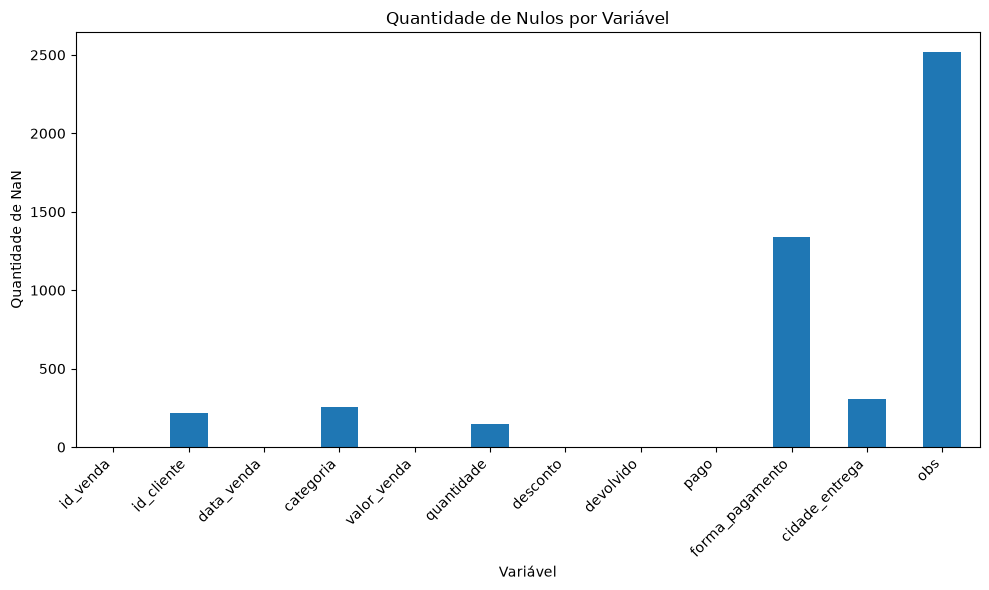

In [87]:
#Verificar quantos NaN existem nas variáveis
df['id_venda'].isna() 
print("Quantidade de Nulos em id_venda: ", df['id_venda'].isna().sum())

df['id_cliente'].isna() 
print("Quantidade de Nulos em id_cliente: ", df['id_cliente'].isna().sum())

df['data_venda'].isna() 
print("Quantidade de Nulos em data_venda: ", df['data_venda'].isna().sum())

df['categoria'].isna() 
print("Quantidade de Nulos em categoria: ", df['categoria'].isna().sum())

df['valor_venda'].isna() 
print("Quantidade de Nulos em valor_venda: ", df['valor_venda'].isna().sum())

df['quantidade'].isna() 
print("Quantidade de Nulos em quantidade: ", df['quantidade'].isna().sum())

df['desconto'].isna() 
print("Quantidade de Nulos em desconto: ", df['desconto'].isna().sum())

df['devolvido'].isna() 
print("Quantidade de Nulos em devolvido: ", df['devolvido'].isna().sum())

df['pago'].isna() 
print("Quantidade de Nulos em pago: ", df['pago'].isna().sum())

df['forma_pagamento'].isna() 
print("Quantidade de Nulos em forma_pagamento: ", df['forma_pagamento'].isna().sum())

df['cidade_entrega'].isna() 
print("Quantidade de Nulos em cidade_entrega: ", df['cidade_entrega'].isna().sum())

df['obs'].isna() 
print("Quantidade de Nulos em obs: ", df['obs'].isna().sum())

#Gráfico de Barras dos NaN
colunas = ['id_venda', 'id_cliente', 'data_venda', 'categoria', 'valor_venda',
           'quantidade', 'desconto', 'devolvido', 'pago', 'forma_pagamento',
           'cidade_entrega', 'obs']

nan_counts = df[colunas].isna().sum()

plt.figure(figsize=(10, 6))
nan_counts.plot(kind='bar')
plt.title('Quantidade de Nulos por Variável')
plt.xlabel('Variável')
plt.ylabel('Quantidade de NaN')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [88]:
#Verificar os tipos de colunas

df.dtypes

#object: vários tipos de data

id_venda           object
id_cliente         object
data_venda         object
categoria          object
valor_venda        object
quantidade         object
desconto           object
devolvido          object
pago               object
forma_pagamento    object
cidade_entrega     object
obs                object
dtype: object

In [89]:
df.head(5)

#Verificar tipos de valores para as variáveis

print("Contagem de valores em categoria:")
print(df['categoria'].value_counts(dropna=False))
print("\n")

print("Contagem de valores em devolvido:")
print(df['devolvido'].value_counts(dropna=False))
print("\n")

print("Contagem de valores em pago:")
print(df['pago'].value_counts(dropna=False))
print("\n")

print("Contagem de valores em forma_pagamento:")
print(df['forma_pagamento'].value_counts(dropna=False))
print("\n")

print("Contagem de valores em cidade_entrega:")
print(df['cidade_entrega'].value_counts(dropna=False))
print("\n")


Contagem de valores em categoria:
categoria
Eletrônicos        1746
Informática        1273
Escritório         1247
Acessórios          979
Móveis              587
Brinquedos          558
Alimentos           549
NaN                 257
ACESSÓRIOS            4
informática           2
INFORMÁTICA           2
ELETRÔNICOS           2
móveis                2
 ELETRÔNICOS          2
Eletrônicos           2
acessórios            2
eletrônicos           2
ALIMENTOS             2
ESCRITÓRIO            2
escritório            1
 Escritóri o          1
  MÓVEIS              1
lEetrônicos           1
  ELETRÔNICOS         1
INFORMÁITCA           1
Escritório            1
 Móveis               1
 Brinquedos           1
Informatica           1
Móveis                1
  INFORMÁTICA         1
alimentos             1
  Eletrônicos         1
  Acessórios          1
Brinquedos            1
Eletrônicos           1
Escritorio            1
Eletronicos           1
Escrtiório            1
ESCRITÓIRO          

In [104]:
#Verificar Duplicatas
print("Verificação de duplicatas em id_venda:")
print(df['id_venda'].value_counts()[df['id_venda'].value_counts() > 1],'\n')
df = df.drop_duplicates(subset='id_venda',keep='first')


print("Verificação de duplicatas em id_cliente:")
print(df['id_cliente'].value_counts().head(10))
df = df.drop_duplicates(subset='id_cliente',keep='first')

Verificação de duplicatas em id_venda:
id_venda
6892    3
1116    2
474     2
3464    2
3927    2
       ..
5713    2
1551    2
3173    2
1455    2
5013    2
Name: count, Length: 193, dtype: int64 

Verificação de duplicatas em id_cliente:
id_cliente
147.0     12
83.0      12
99.0      12
449.0     11
309.0     11
970.0     11
163.0     11
1018.0    11
187.0     10
1047.0    10
Name: count, dtype: int64


In [ ]:
#Mudar objects pra nums
df.dtypes
df.head(5)

valor_venda_temp = pd.to_numeric(df['valor_venda'], errors='coerce')
print("Quantidade de valores não numéricos na coluna valor_venda: ", valor_venda_temp.isna().sum())

quantidade_temp = pd.to_numeric(df['quantidade'], errors='coerce')
print("Quantidade de valores não numéricos na coluna quantidade: ", quantidade_temp.isna().sum())

desconto_temp = pd.to_numeric(df['desconto'], errors='coerce')
print("Quantidade de valores não numéricos na coluna desconto: ", desconto_temp.isna().sum())



Quantidade de valores não numéricos na coluna valor_venda:  0
Quantidade de valores não numéricos na coluna quantidade:  119
Quantidade de valores não numéricos na coluna desconto:  0


np.float64(18153.274267095465)

In [115]:
#Alteração de objects pra numeric no DF
df['valor_venda'] = pd.to_numeric(df['valor_venda'], errors='coerce')
df['quantidade'] = pd.to_numeric(df['quantidade'], errors='coerce')
df['desconto'] = pd.to_numeric(df['desconto'], errors='coerce')

Valor Venda: count    1006.000000
mean      385.503618
std       331.937904
min        17.580000
25%        89.100000
50%       238.240000
75%       681.627500
max      1098.170000
Name: valor_venda, dtype: float64 

Quantidade: count    1006.000000
mean        1.619284
std         1.079518
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: quantidade, dtype: float64 

Desconto: count    1006.000000
mean        0.019583
std         0.061403
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.300000
Name: desconto, dtype: float64


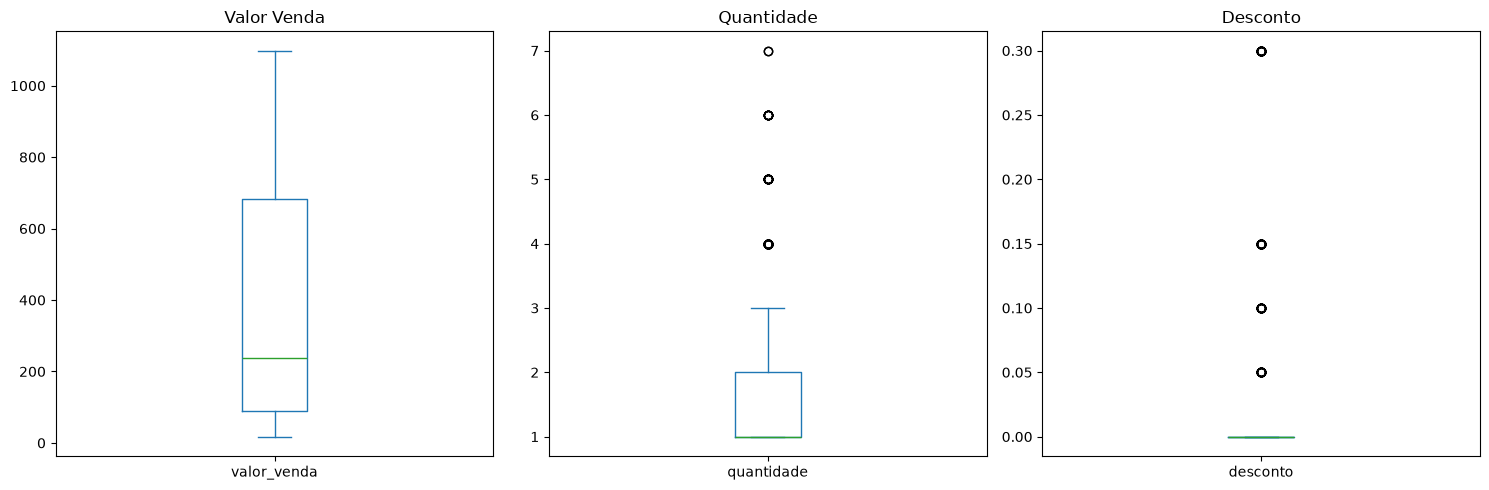

In [128]:
#Verificação de Outliers
print("Valor Venda:", df['valor_venda'].describe(),"\n")

print("Quantidade:",df['quantidade'].describe(),"\n")

print("Desconto:",df['desconto'].describe())


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df['valor_venda'].plot.box(ax=axes[0])
axes[0].set_title('Valor Venda')

df['quantidade'].plot.box(ax=axes[1])
axes[1].set_title('Quantidade')

df['desconto'].plot.box(ax=axes[2])
axes[2].set_title('Desconto')

plt.tight_layout()
plt.show()

Valor Venda: count    1006.000000
mean      385.503618
std       331.937904
min        17.580000
25%        89.100000
50%       238.240000
75%       681.627500
max      1098.170000
Name: valor_venda, dtype: float64 

Quantidade: count    1006.000000
mean        1.619284
std         1.079518
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: quantidade, dtype: float64 

Desconto: count    1006.000000
mean        0.019583
std         0.061403
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.300000
Name: desconto, dtype: float64


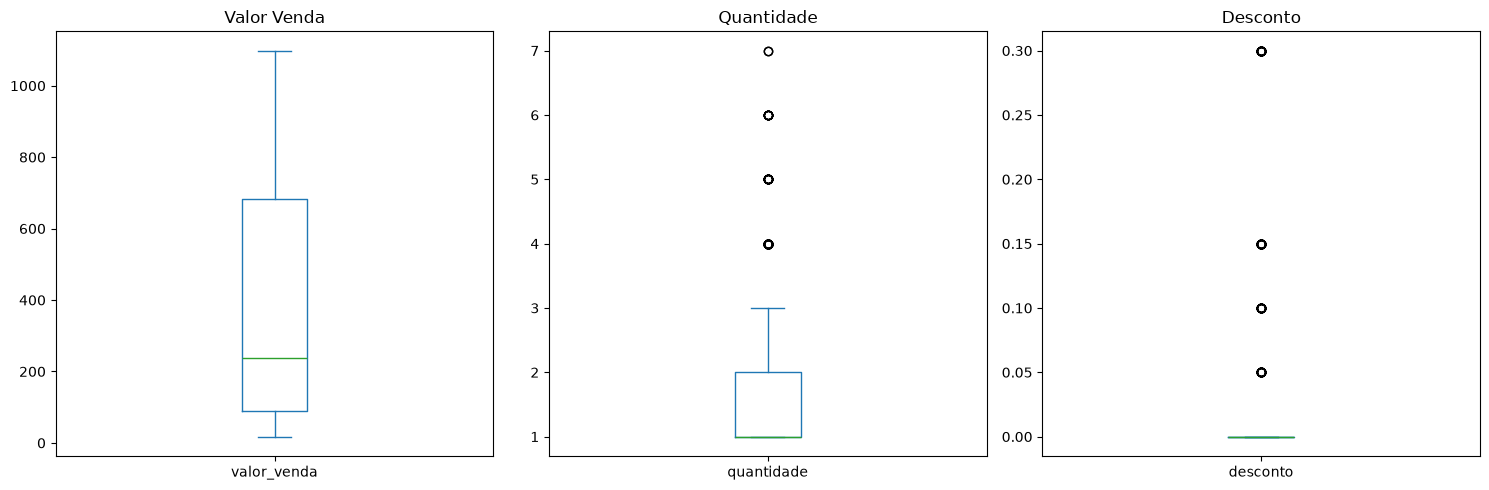

In [ ]:
#Eliminação de Outliers

#valor_venda
df = df.loc[(df['valor_venda'] > 0), :]

#quantidade
df = df.loc[(df['quantidade'] > 0), :]

#desconto
df = df.loc[(df['desconto'] >= 0) & (df['desconto'] < 1), :]

print("Valor Venda:", df['valor_venda'].describe(),"\n")

print("Quantidade:",df['quantidade'].describe(),"\n")

print("Desconto:",df['desconto'].describe())


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df['valor_venda'].plot.box(ax=axes[0])
axes[0].set_title('Valor Venda')

df['quantidade'].plot.box(ax=axes[1])
axes[1].set_title('Quantidade')

df['desconto'].plot.box(ax=axes[2])
axes[2].set_title('Desconto')

plt.tight_layout()
plt.show()

In [100]:
#Limpeza de forma_pagamento

df = df.dropna(subset=['forma_pagamento']) 
df['forma_pagamento'] = df['forma_pagamento'].str.strip().str.lower() 

mapeamento_forma_pagamento = {
    'cartao': 'cartão'

}

df['forma_pagamento'] = df['forma_pagamento'].replace(mapeamento_forma_pagamento)

print("Contagem de valores em forma_pagamento:")
print(df['forma_pagamento'].value_counts(dropna=False))

Contagem de valores em forma_pagamento:
forma_pagamento
cartão      2446
boleto      1190
dinheiro    1148
pix         1124
Name: count, dtype: int64


In [ ]:
#Limpeza de categoria

df = df.dropna(subset=['categoria']) 
df['categoria'] = df['categoria'].str.strip().str.lower() 

mapeamento_categoria = {
    'eletronicos': 'eletrônicos',
    'informatica': 'informática',
    'escritorio': 'escritório',
    'acessorios': 'acessórios',
    'moveis': 'móveis',
}

df['categoria'] = df['categoria'].replace(mapeamento_categoria)

print("Contagem de valores em categoria:")
print(df['categoria'].value_counts(dropna=False))


Contagem de valores em categoria:
categoria
eletrônicos    1420
informática    1036
escritório     1029
acessórios      816
móveis          491
brinquedos      456
alimentos       452
escritóri o       1
informáitca       1
escrtiório        1
escritóiro        1
Name: count, dtype: int64
